# **Project 1: Netflix Data Analysis (End-to-End)**

# **Project Goal**

Analyze Netflix content to discover insights such as:

Movie vs TV show distribution

Most common genres

Content added over time

Top producing countries

Ratings distribution

**Final result:**

Clean dataset

Visual insights

GitHub project

Portfolio-ready notebook

# **Step 1: Create Project Folder**

**Create this structure:**

Netflix-Data-Analysis

│
├── data
│   └── netflix_titles.csv
│
├── notebook
│   └── netflix_analysis.ipynb
│
├── images
│
├── README.md
│
└── requirements.txt

# **Step 2: Install Required Libraries**

Install libraries in Python.

In [1]:
pip install pandas numpy matplotlib seaborn

**Libraries used**

pandas → data manipulation

numpy → numerical operations

matplotlib → visualization

seaborn → statistical visualization

# **Step 3: Import Libraries**

Create a notebook in Jupyter Notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# **Step 4: Load Dataset**

Download Netflix dataset from Kaggle.

In [4]:
df = pd.read_csv("netflix_titles.csv")

Check first rows

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Check dataset info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# **Step 5: Understand Dataset**

Key columns

| Column       | Description        |
| ------------ | ------------------ |
| show_id      | unique id          |
| type         | Movie or TV Show   |
| title        | name of content    |
| director     | director name      |
| cast         | actors             |
| country      | production country |
| release_year | release year       |
| rating       | maturity rating    |
| duration     | length             |
| listed_in    | genre              |


# **Step 6: Data Cleaning**

Check missing values

In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


**Handle missing values**

In [9]:
df["director"].fillna("Unknown", inplace=True)
df["cast"].fillna("Unknown", inplace=True)
df["country"].fillna("Unknown", inplace=True)
df["rating"].fillna("Not Rated", inplace=True)

/tmp/ipykernel_151/1071672122.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["director"].fillna("Unknown", inplace=True)
/tmp/ipykernel_151/1071672122.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

**Remove duplicates**

In [10]:
df.drop_duplicates(inplace=True)

# **Step 7: Basic Data Exploration**

Number of rows and columns

In [11]:
df.shape

(8807, 12)

Content type count

In [12]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


# **Step 8: Visualization 1 — Movies vs TV Shows**

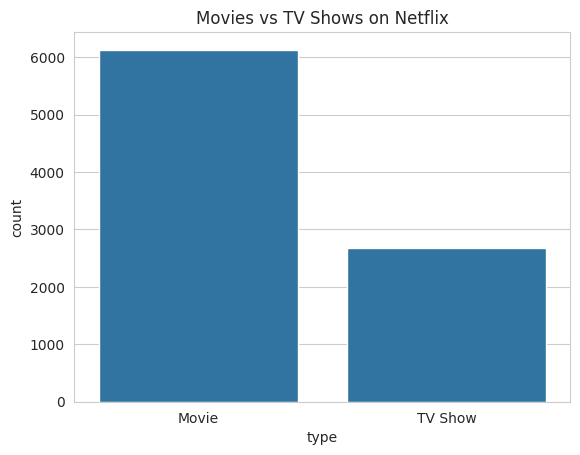

In [13]:
sns.countplot(data=df, x="type")
plt.title("Movies vs TV Shows on Netflix")
plt.show()

**Expected insight:**

Netflix has more movies than TV shows

# **Step 9: Top Countries Producing Netflix Content**

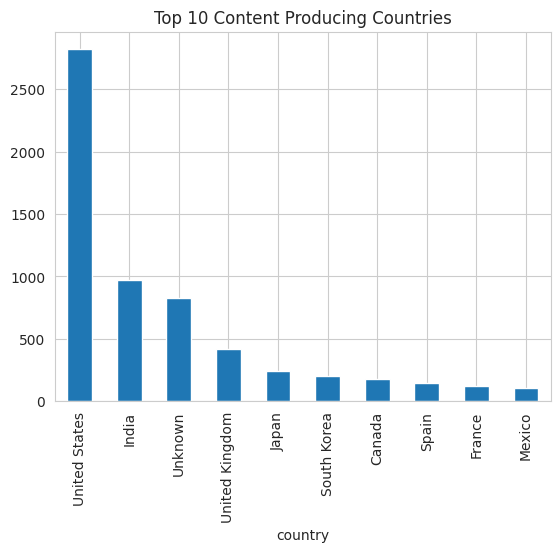

In [14]:
top_countries = df["country"].value_counts().head(10)

top_countries.plot(kind="bar")
plt.title("Top 10 Content Producing Countries")
plt.show()

**Expected insight:**

United States dominates Netflix content.

# **Step 10: Content Added Over Time**

Convert date column

In [16]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')
df['year_added'] = df['date_added'].dt.year

Plot

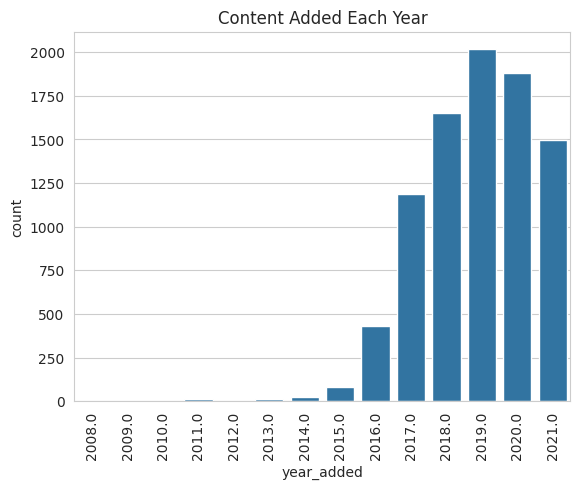

In [17]:
sns.countplot(data=df, x="year_added")
plt.xticks(rotation=90)
plt.title("Content Added Each Year")
plt.show()

**Insight:**

Netflix content increased rapidly after 2015.

# **Step 11: Most Common Ratings**

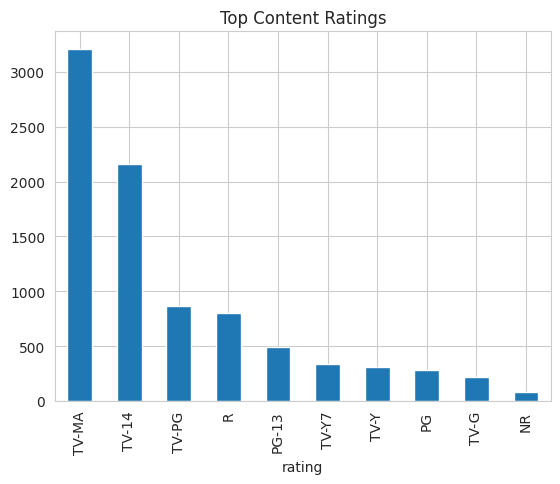

In [18]:
df["rating"].value_counts().head(10).plot(kind="bar")
plt.title("Top Content Ratings")
plt.show()

**Insight:**

TV-MA and TV-14 are most common.

# **Step 12: Genre Analysis**

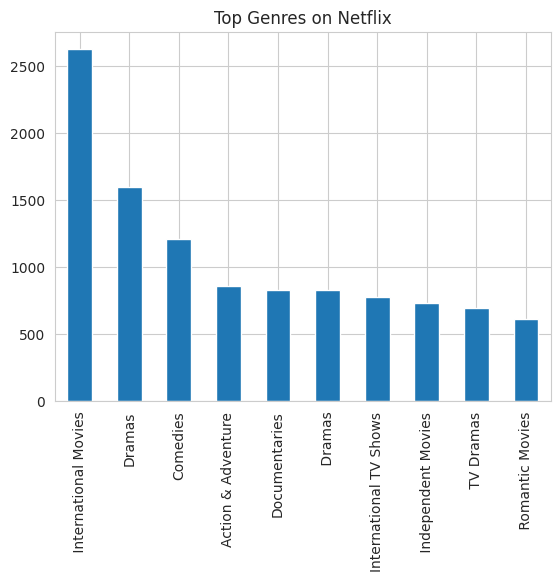

In [19]:
genres = df["listed_in"].str.split(",", expand=True).stack()

genres.value_counts().head(10).plot(kind="bar")
plt.title("Top Genres on Netflix")
plt.show()

**Insight:**

Drama

Comedy

International movies

# **Step 13: Save Cleaned Dataset**

In [21]:
df.to_csv("netflix_cleaned.csv", index=False)

# **Final Result (Portfolio Outcome)**

**Your project demonstrates:**

Data cleaning

Data exploration

Visualization

Insight extraction

Professional documentation

Recruiters see that you understand:

Real-world dataset handling

Data storytelling

Python analytics workflow